UCI Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      193             72             25      169  23.722020   
1      200            107             40       48  39.019181   
2      165             59             26      165  38.047034   
3      152            101             10      300  44.676570   
4      171             85             27      108  29.709714   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.287041   42        0  
1                  1.276820   26        0  
2                  1.303484   37        0  
3                  0.370960   25        0  
4                  0.520054   39        0  

Pima Indians Diabetes Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      145             67             39       39  45.000000   
1      101             75             12       15  29.082089   
2      147             87             50       84  32.060206   
3       80             66  

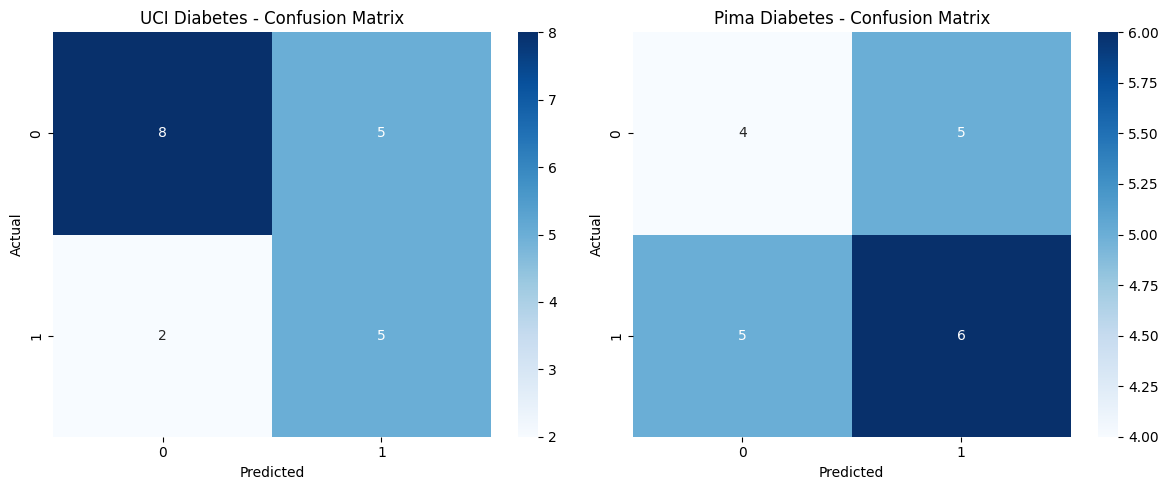

In [38]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load the Datasets
uci_diabetes = pd.read_csv('/content/uci_diabetes.csv')
pima_diabetes = pd.read_csv('/content/pima_diabetes.csv')

# Display Dataset Samples
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train Logistic Regression Models
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate UCI Model
accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci, zero_division=0)
recall_uci = recall_score(y_test_uci, y_pred_uci, zero_division=0)
f1_uci = f1_score(y_test_uci, y_pred_uci, zero_division=0)

# Evaluate Pima Model
accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima, zero_division=0)
recall_pima = recall_score(y_test_pima, y_pred_pima, zero_division=0)
f1_pima = f1_score(y_test_pima, y_pred_pima, zero_division=0)

# Display Results
print("\nUCI Diabetes Dataset - Logistic Regression Results")
print(f"Accuracy : {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall   : {recall_uci:.4f}")
print(f"F1 Score : {f1_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Logistic Regression Results")
print(f"Accuracy : {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall   : {recall_pima:.4f}")
print(f"F1 Score : {f1_pima:.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test_uci, y_pred_uci),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("UCI Diabetes - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test_pima, y_pred_pima),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title("Pima Diabetes - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()